# CFAD Analysis by Weather Classification

Generates contoured frequency by altitude diagrams (CFADs) for MRR (Micro Rain Radar) observations at the Alta and Highland sites, stratified by weather event classification. Each figure contains a 3×3 grid showing reflectivity ($Z_e$), Doppler velocity ($V_r$), and spectral width ($SW$) for each site alongside merged percentile profiles.

**Event types** (set `period` in the *Configuration* cell below):
- `'FR'`  — Frontal events
- `'SIVT'` — South or southwest IVT events
- `'PF'`  — Northwest post-cold frontal events
- `'ALL'` — All available 12-h periods

**Authors:** Jim Steenburgh, Ashley Evans, Michael Wasserstein  
**Date:** June 2024

## Imports

In [1]:
import math
import sys
import matplotlib.pyplot as plt
import numpy as np
import pyart  
import xarray as xr
from MRR_functions import hist2d_height, open_ds



## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



## Configuration
Change `period` to switch event type. All other cells run without modification.

In [2]:
# ── Event classification ─────────────────────────────────────────────────────
# Options: 'FR' | 'SIVT' | 'PF' | 'ALL'
period = 'PF'

# Minimum MRR observations required to include a 12-h period.
# Maximum possible: 360–361.  High values also exclude the spring DST
# transition hour in March (only 11 h of observations that day).
min_obs = 355

# ── Paths ────────────────────────────────────────────────────────────────────
data_path = 'Data/MRR/'
fig_dir   = 'Fig/'


## Load Data

In [3]:
from MRR_functions import open_ds

highland180, highland30, alta180, alta30 = open_ds(data_path, period)


## Define Analysis Periods

Each tuple is a (start, end) UTC timestamp for a 12-h observing window. `title_header` describes the event type and is used in the output filename. These were manually classified before analysis, following methods from [Wasserstein and Steenburgh (2024)](https://journals.ametsoc.org/view/journals/mwre/152/4/MWR-D-23-0206.1.xml).

In [4]:
if period == 'ALL':
    # All available 12-h windows (trimmed to days with >= min_obs samples per site)
    periods_to_analyze = [
        ('2022-11-15 11:00:00', '2023-05-01 10:00:00'),
        ('2023-11-15 11:00:00', '2024-05-01 10:00:00'),
    ]
    title_header = f'All 12-h Periods with \u2265{min_obs} Samples'
    cfad_vmax = 5

elif period == 'FR':
    # Frontal periods with data available at both sites
    periods_to_analyze = [
        ('2022-12-04 23:00:00', '2022-12-05 11:00:00'),
        ('2022-12-27 23:00:00', '2022-12-28 11:00:00'),
        ('2023-01-10 23:00:00', '2023-01-11 11:00:00'),
        ('2023-02-05 11:00:00', '2023-02-05 23:00:00'),
        ('2023-02-21 23:00:00', '2023-02-22 11:00:00'),
        ('2023-03-05 23:00:00', '2023-03-06 11:00:00'),
        ('2023-03-10 23:00:00', '2023-03-11 11:00:00'),
        ('2023-03-15 10:00:00', '2023-03-15 22:00:00'),
        ('2023-03-24 10:00:00', '2023-03-24 22:00:00'),
        ('2024-02-15 11:00:00', '2024-02-15 23:00:00'),
        ('2024-02-26 23:00:00', '2024-02-27 11:00:00'),
        ('2024-03-23 22:00:00', '2024-03-24 10:00:00'),
    ]
    title_header = 'Frontal Events'
    cfad_vmax = 15

elif period == 'SIVT':
    # South or southwest IVT periods with data available at both sites
    periods_to_analyze = [
        ('2022-12-01 23:00:00', '2022-12-02 11:00:00'),
        ('2022-12-11 23:00:00', '2022-12-12 11:00:00'),
        ('2022-12-31 23:00:00', '2023-01-01 11:00:00'),
        ('2023-01-01 11:00:00', '2023-01-01 23:00:00'),
        ('2023-01-09 23:00:00', '2023-01-10 11:00:00'),
        ('2023-01-14 23:00:00', '2023-01-15 11:00:00'),
        ('2023-03-14 22:00:00', '2023-03-15 10:00:00'),
        ('2024-02-01 23:00:00', '2024-02-02 11:00:00'),
        ('2024-02-05 11:00:00', '2024-02-05 23:00:00'),
        ('2024-02-06 23:00:00', '2024-02-07 11:00:00'),
        ('2024-02-19 23:00:00', '2024-02-20 11:00:00'),
        ('2024-03-28 10:00:00', '2024-03-28 22:00:00'),
        ('2024-03-30 22:00:00', '2024-03-31 10:00:00'),
    ]
    title_header = 'South or Southwest IVT Events'
    cfad_vmax = 15

elif period == 'PF':
    # Northwest post-cold frontal periods with data available at both sites
    periods_to_analyze = [
        ('2022-11-28 23:00:00', '2022-11-29 11:00:00'),
        ('2022-12-12 23:00:00', '2022-12-13 11:00:00'),
        ('2022-12-13 11:00:00', '2022-12-13 23:00:00'),
        ('2022-12-13 23:00:00', '2022-12-14 11:00:00'),
        ('2022-12-14 11:00:00', '2022-12-14 23:00:00'),
        ('2022-12-15 11:00:00', '2022-12-15 23:00:00'),
        ('2022-12-28 11:00:00', '2022-12-28 23:00:00'),
        ('2022-12-28 23:00:00', '2022-12-29 11:00:00'),
        ('2023-01-06 11:00:00', '2023-01-06 23:00:00'),
        ('2023-01-11 11:00:00', '2023-01-11 23:00:00'),
        ('2023-01-24 23:00:00', '2023-01-25 11:00:00'),
        ('2023-01-27 23:00:00', '2023-01-28 11:00:00'),
        ('2023-01-28 11:00:00', '2023-01-28 23:00:00'),
        ('2023-02-06 11:00:00', '2023-02-06 23:00:00'),
        ('2023-03-24 22:00:00', '2023-03-25 10:00:00'),
        ('2023-03-27 10:00:00', '2023-03-27 22:00:00'),
        ('2023-12-08 11:00:00', '2023-12-08 23:00:00'),
        ('2023-12-08 23:00:00', '2023-12-09 11:00:00'),
        ('2024-01-05 11:00:00', '2024-01-05 23:00:00'),
        ('2024-01-07 11:00:00', '2024-01-07 23:00:00'),
        ('2024-01-14 11:00:00', '2024-01-14 23:00:00'),
        ('2024-02-02 23:00:00', '2024-02-03 11:00:00'),
        ('2024-02-03 23:00:00', '2024-02-04 11:00:00'),
        ('2024-02-09 11:00:00', '2024-02-09 23:00:00'),
        ('2024-03-24 10:00:00', '2024-03-24 22:00:00'),
        ('2024-04-06 10:00:00', '2024-04-06 22:00:00'),
        ('2024-04-06 22:00:00', '2024-04-07 10:00:00'),
        ('2024-04-15 22:00:00', '2024-04-16 10:00:00'),
    ]
    title_header = 'Northwest Post Cold Frontal Events'
    cfad_vmax = 15

else:
    raise ValueError(f"Unknown period '{period}'. Choose: 'FR', 'SIVT', 'PF', 'ALL'.")


## Colormaps and Variable Settings

In [5]:
variable_dict = {'Ze':            [1.5, -20, 40, r'Reflectivity (dBZ$_{\mathrm{e}}$)'],
                 'W':             [0.5,  -7,  7, r'$V_R$ (m s$^{-1}$)'],
                 'spectralWidth': [0.1,   0,  4, r'Spectral Width (m s$^{-1}$)']}


## Compute Percentile Profiles

In [6]:
def calc_percentile(ds):
    """Compute 25th, 50th, and 75th percentile profiles for Ze, W, and spectralWidth.

    Parameters
    ----------
    ds : xr.Dataset
        MRR dataset with dimensions (time, height_ASL) and variables Ze, W, spectralWidth.

    Returns
    -------
    tuple of 9 arrays
        (q25_Ze, q50_Ze, q75_Ze, q25_W, q50_W, q75_W,
         q25_spectralWidth, q50_spectralWidth, q75_spectralWidth)
    """
    out = []
    for var in ('Ze', 'W', 'spectralWidth'):
        data = ds[var].values
        for q in (25, 50, 75):
            out.append(np.nanpercentile(data, q, axis=0))
    return tuple(out)


(
    q25_Ze_Alta_180,  q50_Ze_Alta_180,  q75_Ze_Alta_180,
    q25_W_Alta_180,   q50_W_Alta_180,   q75_W_Alta_180,
    q25_spectralWidth_Alta_180,  q50_spectralWidth_Alta_180,  q75_spectralWidth_Alta_180,
) = calc_percentile(alta180)

(
    q25_Ze_Alta_30,   q50_Ze_Alta_30,   q75_Ze_Alta_30,
    q25_W_Alta_30,    q50_W_Alta_30,    q75_W_Alta_30,
    q25_spectralWidth_Alta_30,   q50_spectralWidth_Alta_30,   q75_spectralWidth_Alta_30,
) = calc_percentile(alta30)

(
    q25_Ze_Highland_180,  q50_Ze_Highland_180,  q75_Ze_Highland_180,
    q25_W_Highland_180,   q50_W_Highland_180,   q75_W_Highland_180,
    q25_spectralWidth_Highland_180,  q50_spectralWidth_Highland_180,  q75_spectralWidth_Highland_180,
) = calc_percentile(highland180)

(
    q25_Ze_Highland_30,   q50_Ze_Highland_30,   q75_Ze_Highland_30,
    q25_W_Highland_30,    q50_W_Highland_30,    q75_W_Highland_30,
    q25_spectralWidth_Highland_30,   q50_spectralWidth_Highland_30,   q75_spectralWidth_Highland_30,
) = calc_percentile(highland30)


/uufs/chpc.utah.edu/common/home/u1371671/software/pkg/miniconda3/envs/Radar_env_2/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


## Merge 30-m and 180-m Range Gate Data

The 30-m range gate data extends to 930 m AGL (top gate empty). The 180-m range gate begins at 900 m AGL but only covers the upper half of that gate. The merge point uses 810 m AGL (30-m) joined to 900 m AGL (180-m); the upper half of the 30-m gate at 810 m overlaps only 15 m with the 180-m gate. The lowest three range gates are excluded to avoid ground clutter.

In [ ]:
range_gate_start = 3  # start at the 4th gate for analysis

In [8]:
# To merge 30- and 180-m range gate data, find index for where 30-m data = 810 m AGL and 180-m data = 900 m AGL
# 30 meter data goes to 930 m AGL, but that's empty. 900 m is highest available gate, but that only covers half
# of the 900 m AGL 180-m range gate. 810 m is the best compromise, although the upper half of this gate overlaps
# 15 m of the 180-m gate.
mergetop30index     = int(np.where(alta30.height  == 810.)[0])
mergebottom180index = int(np.where(alta180.height == 900.)[0])

# Create merged height axes
alta_height_ASL_merged     = np.concatenate([alta30.height_ASL.values[:mergetop30index+1],     alta180.height_ASL.values[mergebottom180index:]])
highland_height_ASL_merged = np.concatenate([highland30.height_ASL.values[:mergetop30index+1], highland180.height_ASL.values[mergebottom180index:]])

# Ze
alta_q25_merged_Ze = np.concatenate([q25_Ze_Alta_30[:mergetop30index+1],          q25_Ze_Alta_180[mergebottom180index:]])[range_gate_start:]
alta_q50_merged_Ze = np.concatenate([q50_Ze_Alta_30[:mergetop30index+1],          q50_Ze_Alta_180[mergebottom180index:]])[range_gate_start:]
alta_q75_merged_Ze = np.concatenate([q75_Ze_Alta_30[:mergetop30index+1],          q75_Ze_Alta_180[mergebottom180index:]])[range_gate_start:]
highland_q25_merged_Ze = np.concatenate([q25_Ze_Highland_30[:mergetop30index+1],  q25_Ze_Highland_180[mergebottom180index:]])[range_gate_start:]
highland_q50_merged_Ze = np.concatenate([q50_Ze_Highland_30[:mergetop30index+1],  q50_Ze_Highland_180[mergebottom180index:]])[range_gate_start:]
highland_q75_merged_Ze = np.concatenate([q75_Ze_Highland_30[:mergetop30index+1],  q75_Ze_Highland_180[mergebottom180index:]])[range_gate_start:]

# W
alta_q25_merged_W = np.concatenate([q25_W_Alta_30[:mergetop30index+1],          q25_W_Alta_180[mergebottom180index:]])[range_gate_start:]
alta_q50_merged_W = np.concatenate([q50_W_Alta_30[:mergetop30index+1],          q50_W_Alta_180[mergebottom180index:]])[range_gate_start:]
alta_q75_merged_W = np.concatenate([q75_W_Alta_30[:mergetop30index+1],          q75_W_Alta_180[mergebottom180index:]])[range_gate_start:]
highland_q25_merged_W = np.concatenate([q25_W_Highland_30[:mergetop30index+1],  q25_W_Highland_180[mergebottom180index:]])[range_gate_start:]
highland_q50_merged_W = np.concatenate([q50_W_Highland_30[:mergetop30index+1],  q50_W_Highland_180[mergebottom180index:]])[range_gate_start:]
highland_q75_merged_W = np.concatenate([q75_W_Highland_30[:mergetop30index+1],  q75_W_Highland_180[mergebottom180index:]])[range_gate_start:]

# spectralWidth
alta_q25_merged_spectralWidth = np.concatenate([q25_spectralWidth_Alta_30[:mergetop30index+1],          q25_spectralWidth_Alta_180[mergebottom180index:]])[range_gate_start:]
alta_q50_merged_spectralWidth = np.concatenate([q50_spectralWidth_Alta_30[:mergetop30index+1],          q50_spectralWidth_Alta_180[mergebottom180index:]])[range_gate_start:]
alta_q75_merged_spectralWidth = np.concatenate([q75_spectralWidth_Alta_30[:mergetop30index+1],          q75_spectralWidth_Alta_180[mergebottom180index:]])[range_gate_start:]
highland_q25_merged_spectralWidth = np.concatenate([q25_spectralWidth_Highland_30[:mergetop30index+1],  q25_spectralWidth_Highland_180[mergebottom180index:]])[range_gate_start:]
highland_q50_merged_spectralWidth = np.concatenate([q50_spectralWidth_Highland_30[:mergetop30index+1],  q50_spectralWidth_Highland_180[mergebottom180index:]])[range_gate_start:]
highland_q75_merged_spectralWidth = np.concatenate([q75_spectralWidth_Highland_30[:mergetop30index+1],  q75_spectralWidth_Highland_180[mergebottom180index:]])[range_gate_start:]


## Generate CFAD Figure

3×3 grid layout:

|       | Alta (col 1) | Highland (col 2) | Comparison (col 3) |
|-------|-------------|-----------------|--------------------|
| Row 1 | $Z_e$ CFAD | $Z_e$ CFAD | $Z_e$ percentile profiles |
| Row 2 | $V_r$ CFAD | $V_r$ CFAD | $V_r$ percentile profiles |
| Row 3 | $SW$ CFAD | $SW$ CFAD | $SW$ percentile profiles |

CFAD panels show normalized frequency (%) per altitude–variable bin. Altitude rows with total counts below `min_frac_thres` of the row-maximum are masked.

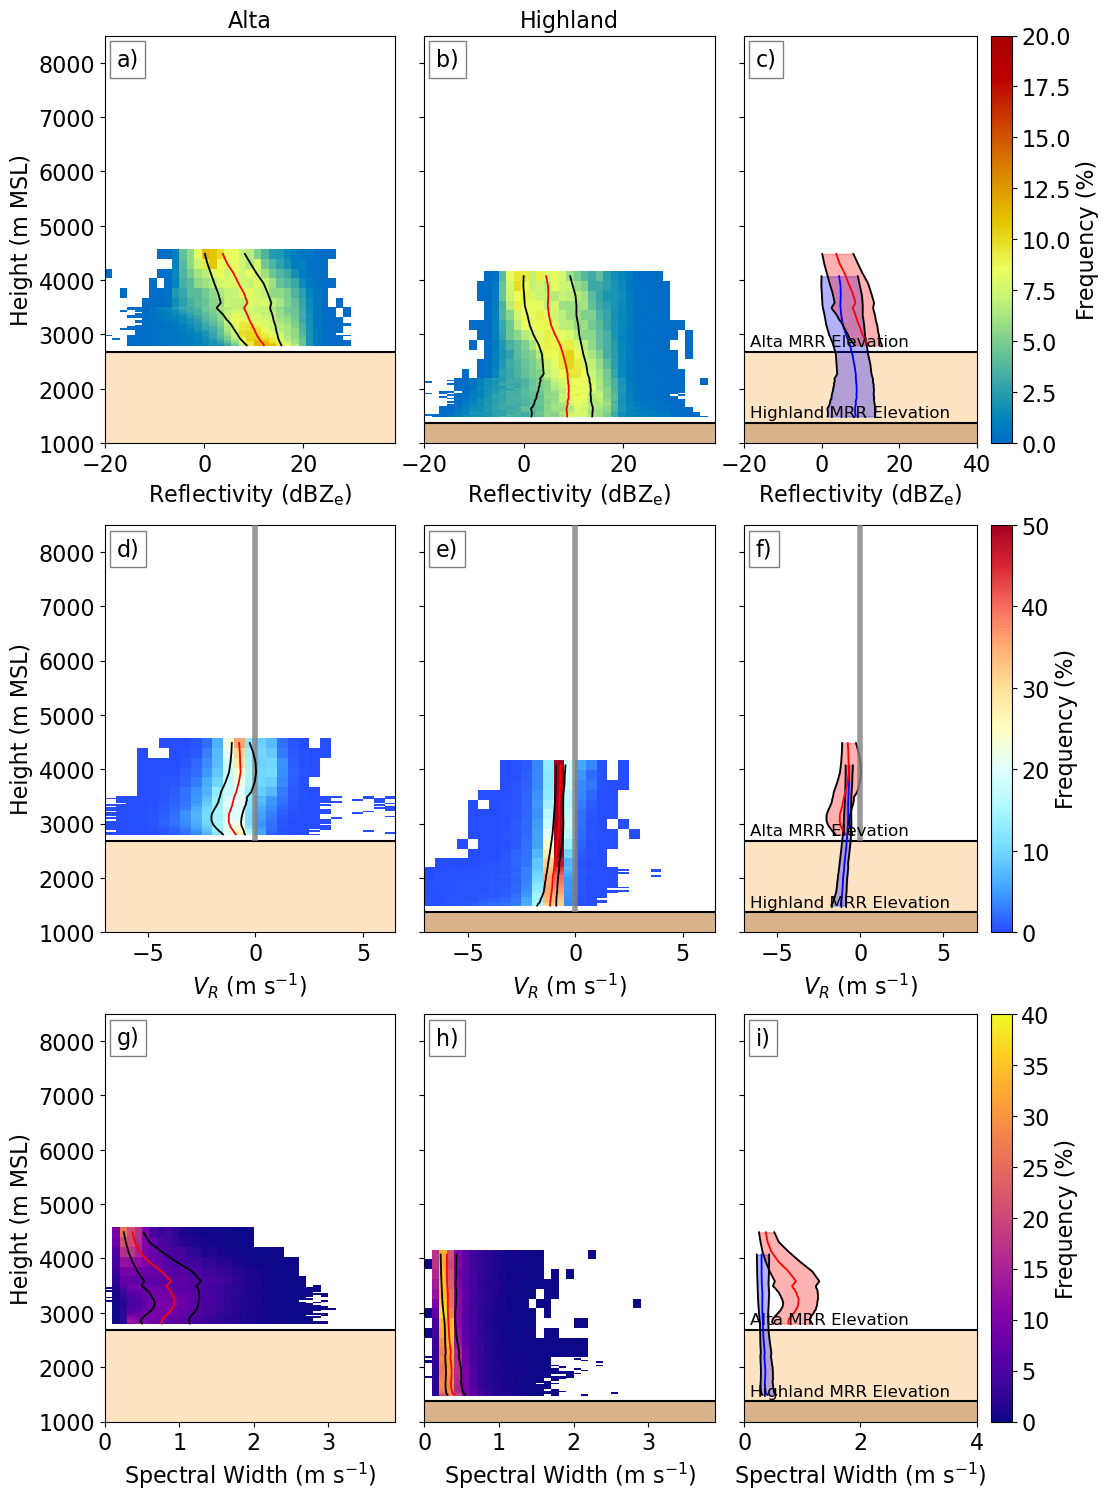

In [ ]:
# Setting for plot
fig_labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)', 'g)', 'h)', 'i)']
fs = 16

# Plot 3x3 CFAD figure
fig, axes = plt.subplots(3, 3, sharex=False, sharey='row', figsize=(12,18)) 
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9 = axes.flatten()

# Loop through all the axes
for plotnum, ax in enumerate(axes.flatten(), start=1):
    # Reflectivity Ze CFAD
    if plotnum == 2:  # Highland Ze
        variable = 'Ze'
        cmap = 'pyart_HomeyerRainbow'
        cfad_vmax = 20
        variable_bins_width, variable_bins_start, variable_bins_stop, xlabel = variable_dict[variable][0], variable_dict[variable][1], variable_dict[variable][2], variable_dict[variable][3]
        data180 = highland180
        data30 = highland30
        q25, q50, q75, height_ASL_merged = highland_q25_merged_Ze, highland_q50_merged_Ze, highland_q75_merged_Ze, highland_height_ASL_merged
        ax.set_xlabel(xlabel, fontsize=fs)
        ax.set_title('Highland', fontsize=fs)
    elif plotnum == 1:  # Alta Ze
        variable = 'Ze'
        cfad_vmax = 20
        cmap = 'pyart_HomeyerRainbow'
        variable_bins_width, variable_bins_start, variable_bins_stop, xlabel = variable_dict[variable][0], variable_dict[variable][1], variable_dict[variable][2], variable_dict[variable][3]
        data180 = alta180
        data30 = alta30
        q25, q50, q75, height_ASL_merged = alta_q25_merged_Ze, alta_q50_merged_Ze, alta_q75_merged_Ze, alta_height_ASL_merged
        ax.set_xlabel(xlabel, fontsize=fs)
        ax.set_title('Alta', fontsize=fs)

    # Doppler Velocity W CFAD
    elif plotnum == 5:  # Highland W
        variable = 'W'
        cfad_vmax = 50
        cmap = 'pyart_RdYlBu11b_r'
        variable_bins_width, variable_bins_start, variable_bins_stop, xlabel = variable_dict[variable][0], variable_dict[variable][1], variable_dict[variable][2], variable_dict[variable][3]
        data180 = highland180
        data30 = highland30
        q25, q50, q75, height_ASL_merged = highland_q25_merged_W, highland_q50_merged_W, highland_q75_merged_W, highland_height_ASL_merged
        ax.set_xlabel(xlabel, fontsize=fs)
        ax.vlines(0, highland180.MRR_elevation, math.ceil((alta180.height_ASL.values[-1] + alta180.range_gate)/500)*500,
                  color='grey', linewidth=4, alpha=0.8, zorder=20)
    elif plotnum == 4:  # Alta W
        variable = 'W'
        cfad_vmax = 50
        variable_bins_width, variable_bins_start, variable_bins_stop, xlabel = variable_dict[variable][0], variable_dict[variable][1], variable_dict[variable][2], variable_dict[variable][3]
        cmap = 'pyart_RdYlBu11b_r'
        data180 = alta180
        data30 = alta30
        q25, q50, q75, height_ASL_merged = alta_q25_merged_W, alta_q50_merged_W, alta_q75_merged_W, alta_height_ASL_merged
        ax.set_xlabel(xlabel, fontsize=fs)
        ax.vlines(0, alta180.MRR_elevation, math.ceil((alta180.height_ASL.values[-1] + alta180.range_gate)/500)*500,
                  color='grey', linewidth=4, alpha=0.8, zorder=20)

    # Spectral Width
    elif plotnum == 8:  # Highland SW
        variable = 'spectralWidth'
        cmap = 'plasma'
        cfad_vmax = 40
        variable_bins_width, variable_bins_start, variable_bins_stop, xlabel = variable_dict[variable][0], variable_dict[variable][1], variable_dict[variable][2], variable_dict[variable][3]
        data180 = highland180
        data30 = highland30
        q25, q50, q75, height_ASL_merged = highland_q25_merged_spectralWidth, highland_q50_merged_spectralWidth, highland_q75_merged_spectralWidth, highland_height_ASL_merged
        ax.set_xlabel(xlabel, fontsize=fs)
    elif plotnum == 7:  # Alta SW
        variable = 'spectralWidth'
        variable_bins_width, variable_bins_start, variable_bins_stop, xlabel = variable_dict[variable][0], variable_dict[variable][1], variable_dict[variable][2], variable_dict[variable][3]
        cmap = 'plasma'
        cfad_vmax = 40
        data180 = alta180
        data30 = alta30
        q25, q50, q75, height_ASL_merged = alta_q25_merged_spectralWidth, alta_q50_merged_spectralWidth, alta_q75_merged_spectralWidth, alta_height_ASL_merged
        ax.set_xlabel(xlabel, fontsize=fs)

    # Set top of y axis to first 500-m increment above highest Alta range gate
    top = math.ceil((alta180.height_ASL.values[-1] + alta180.range_gate)/500)*500

    # Set bottom of y axis to 1000 m
    bottom = 1000

    # Set height bin widths and range for 180-m range gate data
    height_bins_width = data180.range_gate
    height_bins_start = data180.height_ASL[mergebottom180index] - data180.range_gate/2 
    height_bins_stop  = data180.height_ASL[-1] + data180.range_gate/2 

    # Do the plotting for the CFADs
    if plotnum not in [3, 6, 9]:
        # Add panel label
        props = dict(boxstyle='square', facecolor='white', alpha=1, ec='gray')
        ax.text(0.04, 0.925, fig_labels[plotnum - 1], transform=ax.transAxes, fontsize=fs, bbox=props)

        # Calculate 2D histogram for 180-m range gate data
        results = hist2d_height(data180.isel(height_ASL=slice(range_gate_start, -1)), variable, variable_bins_width,
                                variable_bins_start, variable_bins_stop,
                                'height_ASL', height_bins_width,
                                height_bins_start, height_bins_stop)
        hist, height_edges, variable_edges = results

        # Normalize and mask altitude rows with too few counts (< min_frac_thres of row-max)
        min_frac_thres = 0.2
        hist_sum = np.sum(hist, axis=1, keepdims=True)  # Sum over all height bins
        point_thres = min_frac_thres * np.max(hist_sum)
        mask_valid_rows = hist_sum[:, 0] >= point_thres  
        hist_masked = np.where(mask_valid_rows[:, None], hist, np.nan)
        with np.errstate(divide='ignore', invalid='ignore'):
            freq = (hist_masked / hist_sum) * 100
            freq[~mask_valid_rows, :] = np.nan
        nan_freq_180 = np.where(freq == 0, np.nan, freq) # Replace zeros with nan

        # Plot all the percentile lines
        if plotnum in [1, 4, 7]:
            first_all_nan_Alta = np.min(np.where(np.all(np.isnan(nan_freq_180), axis=1))[0])
            ax.plot(q25[:mergetop30index+first_all_nan_Alta+1-3], height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Alta+1], color='black', lw=1.3, zorder=50)
            ax.plot(q75[:mergetop30index+first_all_nan_Alta+1-3], height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Alta+1], color='black', lw=1.3, zorder=50)
            ax.plot(q50[:mergetop30index+first_all_nan_Alta+1-3], height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Alta+1], color='red',   lw=1.3, zorder=50)
        elif plotnum in [2, 5, 8]:
            first_all_nan_Highland = np.min(np.where(np.all(np.isnan(nan_freq_180), axis=1))[0])
            ax.plot(q25[:mergetop30index+first_all_nan_Highland+1-3], height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Highland+1], color='black', lw=1.3, zorder=50)
            ax.plot(q75[:mergetop30index+first_all_nan_Highland+1-3], height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Highland+1], color='black', lw=1.3, zorder=50)
            ax.plot(q50[:mergetop30index+first_all_nan_Highland+1-3], height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Highland+1], color='red',   lw=1.3, zorder=50)

        # Plot 180-m CFAD
        x_mesh, y_mesh = np.meshgrid(variable_edges, height_edges)
        p = ax.pcolormesh(x_mesh, y_mesh, nan_freq_180, cmap=cmap, vmin=0, vmax=cfad_vmax,
                          edgecolors='none', linewidth=0.4, antialiased=True)

        # Calculate 2D histogram for 30-m range gate data
        height_bins_width = data30.range_gate
        height_bins_start = data30.height_ASL[0] - data30.range_gate/2 
        height_bins_stop  = data30.height_ASL[mergetop30index+1] + data30.range_gate/2   
        results = hist2d_height(data30.isel(height_ASL=slice(range_gate_start, -1)), variable, variable_bins_width,
                                variable_bins_start, variable_bins_stop,
                                'height_ASL', height_bins_width,
                                height_bins_start, height_bins_stop)
        hist, height_edges, variable_edges = results

        # Normalize and mask altitude rows with too few counts (< min_frac_thres of row-max)
        hist_sum = np.sum(hist, axis=1, keepdims=True) # Sum over all height bins
        point_thres = min_frac_thres * np.max(hist_sum)
        mask_valid_rows = hist_sum[:, 0] >= point_thres
        hist_masked = np.where(mask_valid_rows[:, None], hist, np.nan)
        with np.errstate(divide='ignore', invalid='ignore'):
            freq = (hist_masked / hist_sum) * 100
            freq[~mask_valid_rows, :] = np.nan
        nan_freq_30 = np.where(freq == 0, np.nan, freq) # Replace zeros with nan

        # Plot 30-m CFAD
        x_mesh, y_mesh = np.meshgrid(variable_edges, height_edges)
        p = ax.pcolormesh(x_mesh, y_mesh, nan_freq_30, cmap=cmap, vmin=0, vmax=cfad_vmax,
                          edgecolors='none', linewidth=0.4, antialiased=True)

        # Ground shading
        if plotnum in [2, 5, 8]:
            ax.axhspan(bottom, data180.MRR_elevation, fc='#d9b38c')
            ax.axhline(data180.MRR_elevation, color='black')
        elif plotnum in [1, 4, 7]:
            ax.axhspan(bottom, data180.MRR_elevation, fc='bisque')
            ax.axhline(data180.MRR_elevation, color='black')
            ax.set_ylabel('Height (m MSL)', fontsize=fs)

        # Set tick sizing
        ax.tick_params(axis='x', labelsize=fs)
        ax.tick_params(axis='y', labelsize=fs)

    # ──────────────────────────────────────────── Percentile comparison plots  ────────────────────────────────────────────
    # Spectral width plot
    if plotnum == 9:
        variable = 'spectralWidth'
        variable_bins_width, variable_bins_start, variable_bins_stop, xlabel = variable_dict[variable][0], variable_dict[variable][1], variable_dict[variable][2], variable_dict[variable][3]
        labelxloc = variable_bins_start + (variable_bins_stop - variable_bins_start) / 40
        # Highland (blue)
        ax.plot(highland_q25_merged_spectralWidth[:mergetop30index+first_all_nan_Highland+1-3], highland_height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Highland+1], color='black', lw=1.3, zorder=4)
        ax.plot(highland_q75_merged_spectralWidth[:mergetop30index+first_all_nan_Highland+1-3], highland_height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Highland+1], color='black', lw=1.3, zorder=4)
        ax.fill_betweenx(highland_height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Highland+1], highland_q25_merged_spectralWidth[:mergetop30index+first_all_nan_Highland+1-3], highland_q75_merged_spectralWidth[:mergetop30index+first_all_nan_Highland+1-3], color='blue', alpha=0.3, zorder=3)
        ax.plot(highland_q50_merged_spectralWidth[:mergetop30index+first_all_nan_Highland+1-3], highland_height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Highland+1], color='blue', lw=1.3, zorder=4)
        # Alta (red)
        ax.plot(alta_q25_merged_spectralWidth[:mergetop30index+first_all_nan_Alta+1-3], alta_height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Alta+1], color='black', lw=1.3, zorder=4)
        ax.plot(alta_q75_merged_spectralWidth[:mergetop30index+first_all_nan_Alta+1-3], alta_height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Alta+1], color='black', lw=1.3, zorder=4)
        ax.fill_betweenx(alta_height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Alta+1], alta_q25_merged_spectralWidth[:mergetop30index+first_all_nan_Alta+1-3], alta_q75_merged_spectralWidth[:mergetop30index+first_all_nan_Alta+1-3], color='red', alpha=0.3, zorder=3)
        ax.plot(alta_q50_merged_spectralWidth[:mergetop30index+first_all_nan_Alta+1-3], alta_height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Alta+1], color='red', lw=1.3, zorder=4)
        
        # Plot settings
        ax.axhspan(bottom, alta180.MRR_elevation, fc='bisque', zorder=1)
        ax.axhline(alta180.MRR_elevation, color='black', zorder=1)
        ax.text(labelxloc, alta180.MRR_elevation+100, 'Alta MRR Elevation', fontsize=12, zorder=50)
        ax.axhspan(bottom, highland180.MRR_elevation, fc='#d9b38c', zorder=2)
        ax.axhline(highland180.MRR_elevation, color='black', zorder=2)
        ax.text(labelxloc, highland180.MRR_elevation+100, 'Highland MRR Elevation', fontsize=12, zorder=50)
        ax.set_xlabel(xlabel, fontsize=fs)
        ax.set_xlim(variable_bins_start, variable_bins_stop)
        ax.set_ylim(bottom, math.ceil((alta180.height_ASL.values[-1] + alta180.range_gate)/500)*500)
        ax.tick_params(axis='x', labelsize=fs)
        ax.tick_params(axis='y', labelsize=fs)

    # Doppler Velocity plot
    elif plotnum == 6:
        variable = 'W'
        variable_bins_width, variable_bins_start, variable_bins_stop, xlabel = variable_dict[variable][0], variable_dict[variable][1], variable_dict[variable][2], variable_dict[variable][3]
        labelxloc = variable_bins_start + (variable_bins_stop - variable_bins_start) / 40
        # Highland (blue)
        ax.plot(highland_q25_merged_W[:mergetop30index+first_all_nan_Highland+1-3], highland_height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Highland+1], color='black', lw=1.3, zorder=4)
        ax.plot(highland_q75_merged_W[:mergetop30index+first_all_nan_Highland+1-3], highland_height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Highland+1], color='black', lw=1.3, zorder=4)
        ax.fill_betweenx(highland_height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Highland+1], highland_q25_merged_W[:mergetop30index+first_all_nan_Highland+1-3], highland_q75_merged_W[:mergetop30index+first_all_nan_Highland+1-3], color='blue', alpha=0.3, zorder=3)
        ax.plot(highland_q50_merged_W[:mergetop30index+first_all_nan_Highland+1-3], highland_height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Highland+1], color='blue', lw=1.3, zorder=4)
        # Alta (red)
        ax.plot(alta_q25_merged_W[:mergetop30index+first_all_nan_Alta+1-3], alta_height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Alta+1], color='black', lw=1.3, zorder=4)
        ax.plot(alta_q75_merged_W[:mergetop30index+first_all_nan_Alta+1-3], alta_height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Alta+1], color='black', lw=1.3, zorder=4)
        ax.fill_betweenx(alta_height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Alta+1], alta_q25_merged_W[:mergetop30index+first_all_nan_Alta+1-3], alta_q75_merged_W[:mergetop30index+first_all_nan_Alta+1-3], color='red', alpha=0.3, zorder=3)
        ax.plot(alta_q50_merged_W[:mergetop30index+first_all_nan_Alta+1-3], alta_height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Alta+1], color='red', lw=1.3, zorder=4)
        
        # Plot settings
        ax.axhspan(bottom, alta180.MRR_elevation, fc='bisque', zorder=1)
        ax.axhline(alta180.MRR_elevation, color='black', zorder=1)
        ax.text(labelxloc, alta180.MRR_elevation+100, 'Alta MRR Elevation', fontsize=12, zorder=50)
        ax.axhspan(bottom, highland180.MRR_elevation, fc='#d9b38c', zorder=2)
        ax.axhline(highland180.MRR_elevation, color='black', zorder=2)
        ax.text(labelxloc, highland180.MRR_elevation+100, 'Highland MRR Elevation', fontsize=12, zorder=50)
        ax.set_xlabel(xlabel, fontsize=fs)
        ax.set_xlim(variable_bins_start, variable_bins_stop)
        ax.set_ylim(bottom, math.ceil((alta180.height_ASL.values[-1] + alta180.range_gate)/500)*500)
        ax.tick_params(axis='x', labelsize=fs)
        ax.tick_params(axis='y', labelsize=fs)
        ax.vlines(0, alta180.MRR_elevation, math.ceil((alta180.height_ASL.values[-1] + alta180.range_gate)/500)*500,
                  color='grey', linewidth=4, alpha=0.8, zorder=20)

    # Reflectivity plot
    elif plotnum == 3:
        variable = 'Ze'
        variable_bins_width, variable_bins_start, variable_bins_stop, xlabel = variable_dict[variable][0], variable_dict[variable][1], variable_dict[variable][2], variable_dict[variable][3]
        labelxloc = variable_bins_start + (variable_bins_stop - variable_bins_start) / 40
        # Highland (blue)
        ax.plot(highland_q25_merged_Ze[:mergetop30index+first_all_nan_Highland+1-3], highland_height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Highland+1], color='black', lw=1.3, zorder=4)
        ax.plot(highland_q75_merged_Ze[:mergetop30index+first_all_nan_Highland+1-3], highland_height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Highland+1], color='black', lw=1.3, zorder=4)
        ax.fill_betweenx(highland_height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Highland+1], highland_q25_merged_Ze[:mergetop30index+first_all_nan_Highland+1-3], highland_q75_merged_Ze[:mergetop30index+first_all_nan_Highland+1-3], color='blue', alpha=0.3, zorder=3)
        ax.plot(highland_q50_merged_Ze[:mergetop30index+first_all_nan_Highland+1-3], highland_height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Highland+1], color='blue', lw=1.3, zorder=4)
        # Alta (red)
        ax.plot(alta_q25_merged_Ze[:mergetop30index+first_all_nan_Alta+1-3], alta_height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Alta+1], color='black', lw=1.3, zorder=4)
        ax.plot(alta_q75_merged_Ze[:mergetop30index+first_all_nan_Alta+1-3], alta_height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Alta+1], color='black', lw=1.3, zorder=4)
        ax.fill_betweenx(alta_height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Alta+1], alta_q25_merged_Ze[:mergetop30index+first_all_nan_Alta+1-3], alta_q75_merged_Ze[:mergetop30index+first_all_nan_Alta+1-3], color='red', alpha=0.3, zorder=3)
        ax.plot(alta_q50_merged_Ze[:mergetop30index+first_all_nan_Alta+1-3], alta_height_ASL_merged[range_gate_start:mergetop30index+first_all_nan_Alta+1], color='red', lw=1.3, zorder=4)
        
        # Plot settings
        ax.axhspan(bottom, alta180.MRR_elevation, fc='bisque', zorder=1)
        ax.axhline(alta180.MRR_elevation, color='black', zorder=1)
        ax.text(labelxloc, alta180.MRR_elevation+100, 'Alta MRR Elevation', fontsize=12, zorder=50)
        ax.axhspan(bottom, highland180.MRR_elevation, fc='#d9b38c', zorder=2)
        ax.axhline(highland180.MRR_elevation, color='black', zorder=2)
        ax.text(labelxloc, highland180.MRR_elevation+100, 'Highland MRR Elevation', fontsize=12, zorder=50)
        ax.set_xlabel(xlabel, fontsize=fs)
        ax.set_xlim(variable_bins_start, variable_bins_stop)
        ax.set_ylim(bottom, math.ceil((alta180.height_ASL.values[-1] + alta180.range_gate)/500)*500)
        ax.tick_params(axis='x', labelsize=fs)
        ax.tick_params(axis='y', labelsize=fs)

    # Add colorbars and figure labels
    if plotnum in [3, 6, 9]:
        cb = plt.colorbar(p, ax=ax)
        cb.ax.tick_params(labelsize=fs) 
        cb.set_label('Frequency (%)', fontsize=fs)
        props = dict(boxstyle='square', facecolor='white', alpha=1, ec='gray')
        ax.text(0.05, 0.925, fig_labels[plotnum - 1], transform=ax.transAxes, fontsize=fs, bbox=props)


# Tighten up the figure and save it
plt.subplots_adjust(hspace=0.2, wspace=0.1)
plt.savefig(fig_dir + f'cfad_Highland_Alta_{period}_v2_norm_{min_frac_thres}.png', dpi=300, bbox_inches='tight')
plt.show()
